In [22]:
import torch
from pathlib import Path

# Load pre-saved MNIST subsets
DATA_DIR = Path("../../exercise_artifacts/data")

train_data = torch.load(DATA_DIR / "mnist_train_1k.pt")
test_data = torch.load(DATA_DIR / "mnist_test_200.pt")

train_images, train_labels = train_data["images"], train_data["labels"]
test_images, test_labels = test_data["images"], test_data["labels"]

print(f"Train: {train_images.shape}, {train_labels.shape}")
print(f"Test:  {test_images.shape}, {test_labels.shape}")

Train: torch.Size([1000, 1, 28, 28]), torch.Size([1000])
Test:  torch.Size([200, 1, 28, 28]), torch.Size([200])


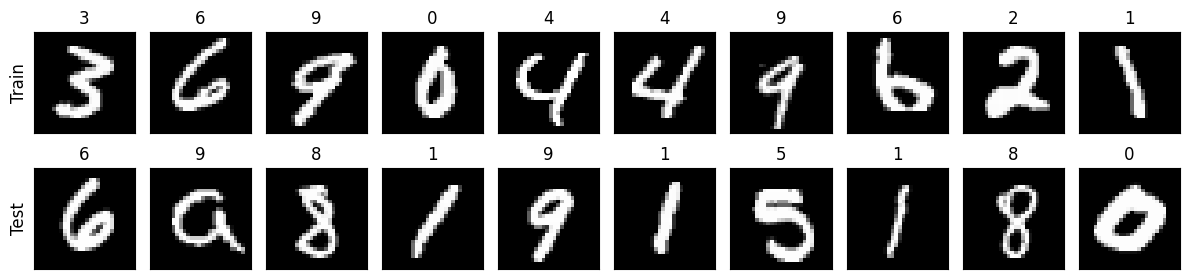

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 10, figsize=(12, 3))

# Train set (top row)
for i in range(10):
    axes[0, i].imshow(train_images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f"{train_labels[i].item()}")
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])

# Test set (bottom row)
for i in range(10):
    axes[1, i].imshow(test_images[i].squeeze(), cmap='gray')
    axes[1, i].set_title(f"{test_labels[i].item()}")
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])

# Add row labels
axes[0, 0].set_ylabel("Train", fontsize=12)
axes[1, 0].set_ylabel("Test", fontsize=12)

plt.tight_layout()
plt.show()

In [24]:
import os, sys

# exercises → unit folder → modules → project_root
MODULES_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
ARTIFACT_CODE = os.path.join(MODULES_ROOT, "exercise_artifacts", "code")
ARTIFACT_MODEL = os.path.join(MODULES_ROOT, "exercise_artifacts", "model")
ARTIFACT_DATA = os.path.join(MODULES_ROOT, "exercise_artifacts", "data")

if ARTIFACT_CODE not in sys.path:
    sys.path.append(ARTIFACT_CODE)

if ARTIFACT_MODEL not in sys.path:
    sys.path.append(ARTIFACT_MODEL)

if ARTIFACT_DATA not in sys.path:
    sys.path.append(ARTIFACT_DATA)

print("Added to sys.path:", ARTIFACT_CODE)
print("Added to sys.path:", ARTIFACT_MODEL)
print("Added to sys.path:", ARTIFACT_DATA)

Added to sys.path: /workspace/modules/exercise_artifacts/code
Added to sys.path: /workspace/modules/exercise_artifacts/model
Added to sys.path: /workspace/modules/exercise_artifacts/data


In [25]:
!pip install torchinfo

In [27]:
from mnist_model import MnistCNN, load_trained_model
from torchinfo import summary

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = MnistCNN().to(device)
print("MnistCNN Summary:")
summary(model, input_size=(1, 1, 28, 28), col_names=["input_size", "output_size", "num_params"])

Device: cpu
MnistCNN Summary:


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MnistCNN                                 [1, 1, 28, 28]            [1, 10]                   --
├─Conv2d: 1-1                            [1, 1, 28, 28]            [1, 16, 28, 28]           160
├─Conv2d: 1-2                            [1, 16, 14, 14]           [1, 32, 14, 14]           4,640
├─Linear: 1-3                            [1, 1568]                 [1, 64]                   100,416
├─Linear: 1-4                            [1, 64]                   [1, 10]                   650
Total params: 105,866
Trainable params: 105,866
Non-trainable params: 0
Total mult-adds (M): 1.14
Input size (MB): 0.00
Forward/backward pass size (MB): 0.15
Params size (MB): 0.42
Estimated Total Size (MB): 0.58

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim

# Create DataLoaders
train_dataset = TensorDataset(train_images, train_labels)
test_dataset = TensorDataset(test_images, test_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    
    train_acc = 100 * correct / len(train_dataset)
    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {train_acc:.1f}%")
